In [1]:
# Variables
flowrate = 20 # [slm] 10 or 20
upstream = True # True to look at z=-40mm (upstream), False z=20mm (downstream)
force_edge_300K = True # True to force the edge of the measurement to be 300K CO2, False to extrapolate the measurements

# Constants
pressure = 120
power = 1000 # [W]

# Enthalpy profiles (Fig. 4, 6)

In [2]:
import wedme
import numpy as np
import matplotlib.pyplot as plt
import toddler
from pathlib import Path
from scipy import interpolate
import os

dir_root = Path(os.getcwd())

dir_out = dir_root / "output" # Storage of the output of this work: flow profiles and fitted parameters
dir_media = dir_out / "media" # Storage of generated media (e.g. plots)
dir_output_data = dir_out / "data" # Storage of generated data (e.g. flow profiles)

dir_media.mkdir(exist_ok=True, parents=True)
dir_output_data.mkdir(exist_ok=True, parents=True)

In [3]:
if upstream:
    z_load = -40
else:
    z_load = 20

stylename = 'paper'
# stylename = 'slide'
# stylename = 'poster'

In [4]:
# Load the file
meas_title = fr"FV {flowrate}slm $\mathrm{{CO_2}}$, {pressure}mbar, 1000W"
meas_filename = fr"fv_{flowrate}slm_CO2_{pressure}mbar_1000W"
path_data = dir_output_data / f"massflux_profiles_{meas_filename}_z{z_load:.0f}.pkl"
if not path_data.is_file():
    raise FileNotFoundError(f"Data file not found: {path_data}. Please run 'parse_data_and_fit.ipynb' to generate the data file before running this notebook.")
obj = toddler.files.saving.load_from_pkl(path_data)

r_sim = obj['r']
z0 = obj['z0']
plots = obj['profiles']
profile_names = obj['profile_names']
massflux_abs = obj['massflux']
massflow_diff = obj['massflow_diff']
massflow_cum = obj['massflow_cum']
massflow_cum_slm = obj['massflow_cum_slm']
heatflux = obj['heatflux']
heatflux_diff = obj['heatflux_diff']
heatflux_cum = obj['heatflux_cum']
velocity = obj['velocity']
successes = obj['successes']
ressum = obj['ressum']
specific_enthalpy_sim = obj['specific_enthalpy']
power_fraction = obj['power_fraction']
SEI = obj['SEI']
pressure = obj['pressure']
flowrate = obj['flowrate']
power = obj['power']
temperature = obj['temperature']
CO2 = obj['CO2']
CO = obj['CO']
O2 = obj['O2']
O = obj['O']

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


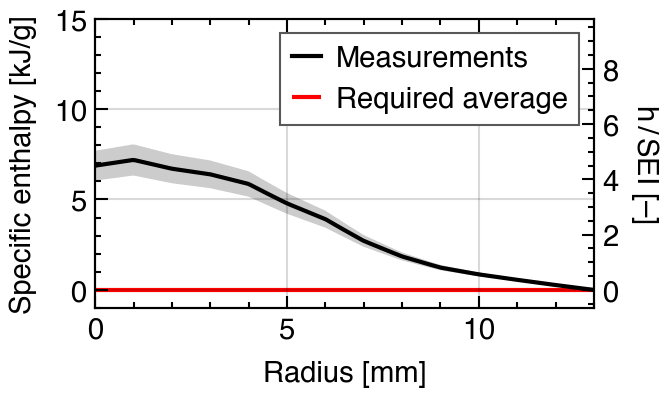

In [ ]:
if stylename == 'slide':
    wedme.figure.slide()
elif stylename == 'paper':
    wedme.figure.paper(figsize=(wedme.PAPER_HSCW,  wedme.PAPER_HSCW / 1.618))
elif stylename == 'poster':
    wedme.figure.poster(figsize=(wedme.A0_FW*0.25, wedme.A0_EH))
else:
    plt.figure()

ymax = round(max(specific_enthalpy_sim/1e6) * 1.1, 0)
ymax = 15
ymin = -1

# See Table S1 of 10.1021/acsenergylett.1c01206
err_ref = np.array([300, 4000, 6000])
T_err_ref = np.array([0.04, 0.1, 0.15])
CO2_err_ref = np.array([0.04, 0.09, 0.16])
CO_err_ref = np.array([0.10, 0.12, 0.15])
O2_err_ref = np.array([0.03, 0.08, 0.12])
O_err_ref = np.array([0.12, 0.08, 0.1])

# Interpolate the errors to the measured temperature and calculate the absolute errors
T_err = interpolate.interp1d(err_ref, T_err_ref, fill_value='nearest')(temperature)*temperature
CO2_err = interpolate.interp1d(err_ref, CO2_err_ref, fill_value='nearest')(temperature)*CO2
CO_err = interpolate.interp1d(err_ref, CO_err_ref, fill_value='nearest')(temperature)*CO
O2_err = interpolate.interp1d(err_ref, O2_err_ref, fill_value='nearest')(temperature)*O2
O_err = interpolate.interp1d(err_ref, O_err_ref, fill_value='nearest')(temperature)*O

# Assume that the relative error in specific enthalpy is the maximum of the relative errors in temperature and species concentrations
h_err_max_rel = interpolate.interp1d(err_ref, np.max([T_err_ref, CO2_err_ref, CO_err_ref, O2_err_ref, O_err_ref], axis=0))(temperature)

l = plt.plot(r_sim, specific_enthalpy_sim/1e6, 'k-', label="Measurements")
plt.fill_between(r_sim,
                 specific_enthalpy_sim*(1 - h_err_max_rel)/1e6,
                 specific_enthalpy_sim*(1 + h_err_max_rel)/1e6,
                 color=l[0].get_color(),
                 alpha=0.2,
                 ec=None)
plt.ylim(ymin, ymax)
plt.xlim(0, 13)
plt.xlabel("Radius [mm]")
plt.ylabel("Specific enthalpy [kJ/g]")
plt.hlines(SEI*1e-6*power_fraction, 0, 13, 'r', '-', label="Required average", zorder=-1000)
plt.legend(loc='upper right')

# Second y-axis
ax2 = plt.gca().twinx()
ax2.set_ylim(ymin/SEI*1e6, ymax/SEI*1e6)
plt.grid(False)
plt.ylabel(r"$h\,/\, SEI$ [$\endash$]", rotation=-90, labelpad=10)
plt.yticks([0, 2, 4, 6, 8])

plt.savefig(dir_media / f"{meas_filename}_z{z0:.0f}_enthalpy_{stylename}.pdf", bbox_inches='tight')
plt.show()

# Composition profiles (Fig. 3)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


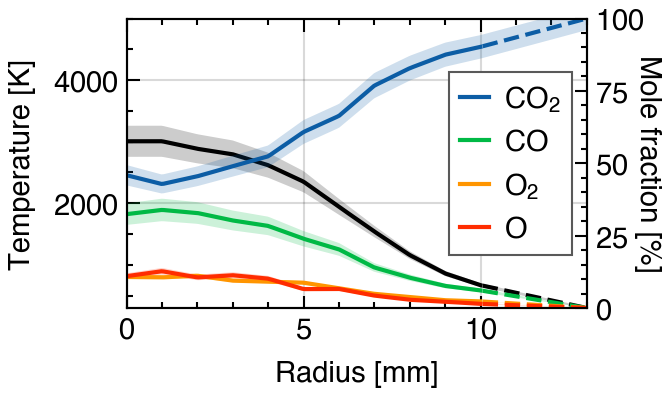

In [6]:
if stylename == 'slide':
    wedme.figure.slide()
elif stylename == 'paper':
    wedme.figure.paper(figsize=(wedme.PAPER_HSCW,  wedme.PAPER_HSCW / 1.618))
elif stylename == 'poster':
    wedme.figure.poster(figsize=(wedme.A0_FW*0.25, wedme.A0_EH))
else:
    plt.figure()

idx_int = (r_sim > 10)


plt.plot(r_sim[~idx_int], temperature[~idx_int], color='k')
plt.plot(r_sim[idx_int], temperature[idx_int], '--', color='k')
plt.fill_between(r_sim, temperature - T_err, temperature + T_err, color='k', alpha=0.2, label='Estimated uncertainty', ec=None)


plt.xlim(0, 13)
plt.ylim(300, 5000)
plt.xlabel("Radius [mm]")
plt.ylabel("Temperature [K]")

# Second y-axis
ax2 = plt.gca().twinx()
plt.grid(False)
plt.plot(r_sim[~idx_int], CO2[~idx_int]*100, label=r"$\mathrm{CO_2}$", color='C0')
plt.plot(r_sim[idx_int], CO2[idx_int]*100, '--', label=r"$\mathrm{CO_2}$", color='C0')
plt.fill_between(r_sim, (CO2 - CO2_err)*100, (CO2 + CO2_err)*100, color='C0', alpha=0.2, ec=None)

plt.plot(r_sim[~idx_int], CO[~idx_int]*100, label=r"$\mathrm{CO}$", color='C1')
plt.plot(r_sim[idx_int], CO[idx_int]*100, '--', label=r"$\mathrm{CO}$", color='C1')
plt.fill_between(r_sim, (CO - CO_err)*100, (CO + CO_err)*100, color='C1', alpha=0.2, ec=None)

plt.plot(r_sim[~idx_int], O2[~idx_int]*100, label=r"$\mathrm{O_2}$", color='C2')
plt.plot(r_sim[idx_int], O2[idx_int]*100, '--', label=r"$\mathrm{O_2}$", color='C2')
plt.fill_between(r_sim, (O2 - O2_err)*100, (O2 + O2_err)*100, color='C2', alpha=0.2, ec=None)

plt.plot(r_sim[~idx_int], O[~idx_int]*100, label=r"$\mathrm{O}$", color='C3')
plt.plot(r_sim[idx_int], O[idx_int]*100, '--', label=r"$\mathrm{O}$", color='C3')
plt.fill_between(r_sim, (O - O_err)*100, (O + O_err)*100, color='C3', alpha=0.2, ec=None)
plt.ylim(0, 100)
plt.xlim(0, 13)
wedme.unique_legend()
plt.ylabel(r"Mole fraction [%]", rotation=270)

plt.savefig(dir_media / f"{meas_filename}_z{z0:.0f}_tempcomp_{stylename}.pdf", bbox_inches='tight')
plt.show()